# PHYS 410 — Numerical ODEs with `scipy.integrate.odeint`

Companion to the Week 2–3 lectures: *"ODEs, numerical convergence, stability"* and
*"ODEs and python, drag"* / *"Drag and projectiles"* (Taylor Ch. 1–2).

**On the "PDE" half of the request:** PHYS 410 doesn't actually use PDEs anywhere in
the syllabus. Every equation of motion you'll meet this semester — Newton's 2nd law,
Lagrange's/Hamilton's equations, Euler's equations for rigid bodies, motion in
rotating frames — is an **ODE in the single variable $t$**. (PDEs show up once you
add spatial fields, e.g. fluid dynamics — not this course.) So this notebook is
entirely about ODEs, which is what you actually need.

## Part A — Why: turning $F=ma$ into something a computer can solve

Newton's 2nd law for 1D motion with linear drag:
$$m\dot v = -mg - bv$$

This is a **second-order** ODE in position $x(t)$, since $v = \dot x$. `odeint`
(and every general-purpose ODE solver) only knows how to solve **first-order**
systems:
$$\dot{\mathbf Y} = f(\mathbf Y, t)$$

**Trick:** define a state vector $\mathbf Y = [x, v]$. Then
$$\dot{\mathbf Y} = \begin{bmatrix}\dot x\\ \dot v\end{bmatrix} = \begin{bmatrix}v\\ -g - (b/m)v\end{bmatrix}$$

Any $n$-th order scalar ODE becomes an $n$-dimensional first-order system this way.
This is **the** recipe you reuse all semester — central forces, Euler's equations,
non-inertial frames — all reduce to picking a state vector and writing `rhs(Y, t)`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Part B — Build intuition first: hand-rolled Euler's method

Euler's method is just the definition of a derivative, solved for the next point:
$$\mathbf Y_{n+1} = \mathbf Y_n + h\, f(\mathbf Y_n, t_n)$$

It's the crudest possible integrator. Using it here — before trusting a black-box
solver — is what makes "numerical convergence" and "stability" concrete rather than
abstract lecture words.

In [2]:
def euler_integrate(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    for i in range(len(t) - 1):
        h = t[i + 1] - t[i]
        y[i + 1] = y[i] + h * np.array(f(y[i], t[i]))
    return y

Test case: **linear** drag has a closed-form solution, so we can check the
numerical answer against the exact one.

$$v(t) = \left(v_0 + \frac{mg}{b}\right)e^{-bt/m} - \frac{mg}{b}$$

In [3]:
g, b, m = 9.8, 0.2, 1.0

def linear_drag_rhs(Y, t):
    x, v = Y
    return [v, -g - (b / m) * v]

def linear_drag_exact(t, v0):
    vterm = m * g / b
    v = (v0 + vterm) * np.exp(-b * t / m) - vterm
    x = -vterm * t + (m / b) * (v0 + vterm) * (1 - np.exp(-b * t / m))
    return x, v

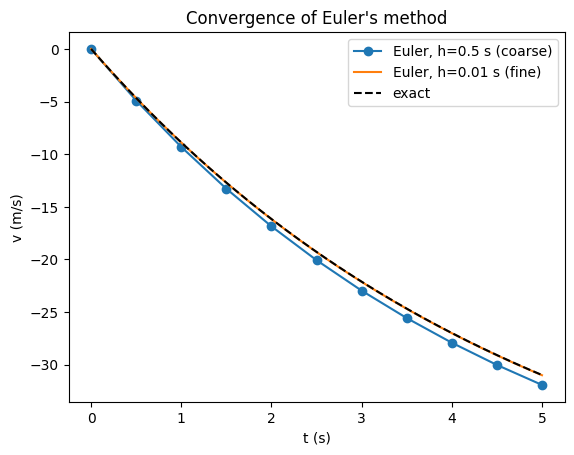

In [4]:
y0 = [0.0, 0.0]                      # dropped from rest
t_coarse = np.linspace(0, 5, 11)     # h = 0.5 s  -- too coarse
t_fine = np.linspace(0, 5, 501)      # h = 0.01 s -- fine

Y_coarse = euler_integrate(linear_drag_rhs, y0, t_coarse)
Y_fine = euler_integrate(linear_drag_rhs, y0, t_fine)
x_exact, v_exact = linear_drag_exact(t_fine, y0[1])

plt.figure()
plt.plot(t_coarse, Y_coarse[:, 1], 'o-', label='Euler, h=0.5 s (coarse)')
plt.plot(t_fine, Y_fine[:, 1], '-', label='Euler, h=0.01 s (fine)')
plt.plot(t_fine, v_exact, 'k--', label='exact')
plt.xlabel('t (s)'); plt.ylabel('v (m/s)')
plt.legend(); plt.title("Convergence of Euler's method")
plt.show()

In [5]:
err_coarse = np.max(np.abs(Y_coarse[:, 1] - linear_drag_exact(t_coarse, y0[1])[1]))
err_fine = np.max(np.abs(Y_fine[:, 1] - v_exact))
print(f"Euler max error, h=0.5s : {err_coarse:.4f}")
print(f"Euler max error, h=0.01s: {err_fine:.4f}")

Euler max error, h=0.5s : 0.9408
Euler max error, h=0.01s: 0.0180


**Takeaway:** shrinking $h$ by 50x shrinks the error by roughly 50x too — Euler
is first-order accurate, error $\sim O(h)$. That's what "convergence" means
concretely. Push $h$ too large on a stiffer problem (bigger $b/m$) and the coarse
curve doesn't just get less accurate — it blows up. That's the "stability" half of
the lecture title.

## Part C — `scipy.integrate.odeint`: same problem, real solver

```
odeint(func, y0, t, args=())
```
- `func(y, t, *args) -> dy/dt` — **note the argument order is `(y, t)`**
- `y0` — initial state vector
- `t` — the times you want **output** at, not the internal step size

Under the hood it's **LSODA**: an adaptive-step solver that automatically switches
between a method suited to smooth ("non-stiff") problems and one suited to "stiff"
problems (fast and slow timescales mixed together). You tell it where you want the
answer; it decides its own internal step size and keeps refining until the local
error is below a tolerance (`rtol`/`atol` kwargs — defaults are fine for this
course).

In [6]:
sol = odeint(linear_drag_rhs, y0, t_fine)
v_ode = sol[:, 1]

print(f"odeint max error : {np.max(np.abs(v_ode - v_exact)):.2e}")

odeint max error : 1.13e-08


`odeint`'s error is many orders of magnitude smaller than even the fine-step
Euler result, using the *same* output times array — it isn't actually taking 501
fixed steps internally, it's adapting.

## Part D — The real lecture problem: quadratic drag has no closed form

$F_\text{drag} = -c\,v|v|$ (quadratic in speed) is the realistic regime for a
thrown ball, not linear drag. The coupled $x$/$y$ equations have no elementary
antiderivative — this is exactly *why* Taylor Ch. 2 turns to numerics here.

State vector for 2D projectile motion: $\mathbf Y = [x, y, v_x, v_y]$
$$\dot{\mathbf Y} = \left[v_x,\ v_y,\ -\frac{c}{m}v_x|\mathbf v|,\ -g-\frac{c}{m}v_y|\mathbf v|\right]$$

In [7]:
c_over_m = 0.02   # drag coefficient / mass -- tune to match a real ball

def projectile_quad_drag(Y, t):
    x, y, vx, vy = Y
    speed = np.hypot(vx, vy)
    ax = -c_over_m * speed * vx
    ay = -g - c_over_m * speed * vy
    return [vx, vy, ax, ay]

v0, angle = 40.0, np.radians(45)
Y0 = [0, 0, v0 * np.cos(angle), v0 * np.sin(angle)]
t = np.linspace(0, 6, 400)

sol_drag = odeint(projectile_quad_drag, Y0, t)

above = sol_drag[:, 1] >= 0          # stop plotting once it hits the ground
x_d, y_d = sol_drag[above, 0], sol_drag[above, 1]

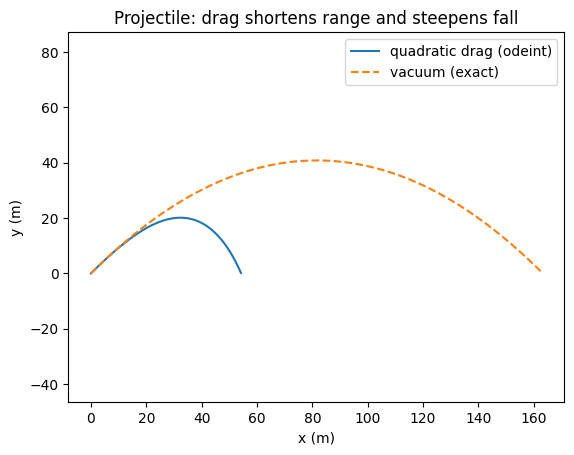

Range with drag : 54.2 m
Range in vacuum : 162.9 m


In [8]:
# Compare against the vacuum (no-drag) trajectory, which DOES have a closed
# form -- a sanity check you should run on every homework problem.
x_vac = v0 * np.cos(angle) * t
y_vac = v0 * np.sin(angle) * t - 0.5 * g * t**2
above_vac = y_vac >= 0

plt.figure()
plt.plot(x_d, y_d, label='quadratic drag (odeint)')
plt.plot(x_vac[above_vac], y_vac[above_vac], '--', label='vacuum (exact)')
plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.legend(); plt.title('Projectile: drag shortens range and steepens fall')
plt.axis('equal')
plt.show()

print(f"Range with drag : {x_d[-1]:.1f} m")
print(f"Range in vacuum : {x_vac[above_vac][-1]:.1f} m")

## Part E — The reusable recipe for the rest of the semester

Every later topic (two-body central forces Ch. 8, Euler's equations for rigid
bodies Ch. 10, rotating frames Ch. 9) follows the same three steps:

1. Write Newton's 2nd law / Euler's equations for the system.
2. Pick a state vector $\mathbf Y$ that makes it first-order (positions + velocities,
   or angular velocities, etc.).
3. Write `rhs(Y, t) = dY/dt` and hand it to `odeint`.

Skeleton for a central-force problem (Ch. 8), force $\mathbf F(r) = -\frac{GM}{r^2}\hat r$:

```python
def central_force_rhs(Y, t, GM):
    x, y, vx, vy = Y
    r = np.hypot(x, y)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    return [vx, vy, ax, ay]

sol = odeint(central_force_rhs, Y0, t, args=(GM,))
```

The `args=(...)` kwarg is how extra parameters (`GM` here) get passed through
`odeint` into your `rhs` function without hardcoding them.

**One API gotcha to remember:** `odeint`'s signature is `f(y, t)` — state first,
time second — which is backwards from `solve_ivp` (`f(t, y)`), the newer interface
the syllabus doesn't mention but you'll see referenced elsewhere. Stick with
`odeint` for this course since that's what's linked in the syllabus, but if you
ever copy an example off the internet and get shape errors, check which convention
it's using first.